## Лабораторная работа № 2 
## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

### Часть 2

В данной части работы рассмотрены:
* подготовка признаков для рашения задачи **градиентного бустинга** на деревьях решений;
* создание и обучение модели градиентного бустинга;
* оценка качества модели.

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.feature import VectorAssembler, StringIndexer, Binarizer, Bucketizer
from pyspark.ml.functions import vector_to_array
from pyspark.ml.classification import GBTClassifier, GBTClassificationModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql import Window
from pyspark.sql.functions import col, when

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("Lab_2_GB")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    # КРИТИЧЕСКИЕ настройки памяти
    conf.set("spark.driver.memory", "8g")           # Увеличил драйвер
    conf.set("spark.executor.memory", "6g")         # Уменьшил исполнитель
    conf.set("spark.memory.fraction", "0.8")        # Больше для execution
    conf.set("spark.memory.storageFraction", "0.3") # Меньше для хранения
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [5]:
database_name = "database"

test_data_name = 'test_data'
train_data_name = 'train_data'
path_test = f"{database_name}/{test_data_name}"
path_train = f"{database_name}/{train_data_name}"

test_df = spark.read.parquet(path_test)
train_df = spark.read.parquet(path_train)

def print_df(df):
    return df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

In [6]:
train_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- rn: short (nullable = true)
 |-- pre_loans90: short (nullable = true)
 |-- pre_loans_total_overdue: float (nullable = true)
 |-- pre_loans3060: short (nullable = true)
 |-- pre_maxover2limit: float (nullable = true)
 |-- pre_util: float (nullable = true)
 |-- pre_over2limit: float (nullable = true)
 |-- pre_loans530: short (nullable = true)
 |-- pre_loans_outstanding: float (nullable = true)
 |-- pre_loans_credit_limit: float (nullable = true)
 |-- pre_loans_credit_cost_rate: float (nullable = true)
 |-- is_zero_loans90: byte (nullable = true)
 |-- pclose_flag: byte (nullable = true)
 |-- fclose_flag: byte (nullable = true)



In [7]:
test_df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- rn: short (nullable = true)
 |-- pre_loans90: short (nullable = true)
 |-- pre_loans_total_overdue: float (nullable = true)
 |-- pre_loans3060: short (nullable = true)
 |-- pre_maxover2limit: float (nullable = true)
 |-- pre_util: float (nullable = true)
 |-- pre_over2limit: float (nullable = true)
 |-- pre_loans530: short (nullable = true)
 |-- pre_loans_outstanding: float (nullable = true)
 |-- pre_loans_credit_limit: float (nullable = true)
 |-- pre_loans_credit_cost_rate: float (nullable = true)
 |-- is_zero_loans90: byte (nullable = true)
 |-- pclose_flag: byte (nullable = true)
 |-- fclose_flag: byte (nullable = true)



#### Постановка задачи

Для датасета, заданного представленными колонками, требуется построить модель градиентного бустинга на деревьях решений для оценки факта того, является ли отзыв полезным, по всем остальным признакам.

Для оценки качества обучения следует использовать метрики Precision и Recall. Оценить максимально возможное значение точности при полноте не менее 60%.

#### Подготовка и кодирование признаков

Для корректной работы трансформеров и модели преобразуем столбец `helpfulness_ratio` к типу `DoubleType`, а столбец `is_helpful` к типу `IntegerType`.

In [8]:
train_target_data = spark.read.csv('../data/train_target.csv', header=True, inferSchema=True)

from pyspark.sql import functions as F

train_merged = train_df.groupBy("id").agg(
    F.count("*").alias("num_loans"),
    # Суммы просрочек
    F.sum("pre_loans90").alias("sum_loans90"),
    F.sum("pre_loans_total_overdue").alias("sum_total_overdue"),
    F.sum("pre_loans3060").alias("sum_loans3060"),
    F.sum("pre_loans530").alias("sum_loans530"),
    
    # Кредитная нагрузка
    F.mean("pre_util").alias("avg_util"),
    F.max("pre_util").alias("max_util"),
    F.mean("pre_over2limit").alias("avg_over2limit"),
    
    # Максимальные значения
    F.max("pre_maxover2limit").alias("max_overdue_ratio"),
    
    # Финансовые показатели
    F.sum("pre_loans_outstanding").alias("sum_outstanding"),
    F.sum("pre_loans_credit_limit").alias("sum_credit_limit"),
    F.mean("pre_loans_credit_cost_rate").alias("avg_credit_cost"),
    
    # Флаги
    F.min("is_zero_loans90").alias("never_serious_overdue"),
    F.max("pclose_flag").alias("has_pclose_flag"),
    F.max("fclose_flag").alias("has_fclose_flag")
).join(
    train_target_data.select("id", "flag"),
    on="id",
    how="inner"
)

print(f"Объединено: {train_merged.count()} клиентов")
print(f"Колонки: {train_merged.columns}")
print(f"Всего признаков: {len(train_merged.columns) - 2} (без id и flag)")

# Проверка баланса
train_merged.groupBy("flag").count().show()

Объединено: 3000000 клиентов
Колонки: ['id', 'num_loans', 'sum_loans90', 'sum_total_overdue', 'sum_loans3060', 'sum_loans530', 'avg_util', 'max_util', 'avg_over2limit', 'max_overdue_ratio', 'sum_outstanding', 'sum_credit_limit', 'avg_credit_cost', 'never_serious_overdue', 'has_pclose_flag', 'has_fclose_flag', 'flag']
Всего признаков: 15 (без id и flag)
+----+-------+
|flag|  count|
+----+-------+
|   1| 106442|
|   0|2893558|
+----+-------+



In [9]:
test_target_data = spark.read.csv('../data/test_target.csv', header=True, inferSchema=True)

from pyspark.sql import functions as F

# Сначала нужно выполнить агрегацию для test_df, как вы делали для train
test_merged = test_df.groupBy("id").agg(
    F.count("*").alias("num_loans"),
    # Суммы просрочек
    F.sum("pre_loans90").alias("sum_loans90"),
    F.sum("pre_loans_total_overdue").alias("sum_total_overdue"),
    F.sum("pre_loans3060").alias("sum_loans3060"),
    F.sum("pre_loans530").alias("sum_loans530"),
    
    # Кредитная нагрузка
    F.mean("pre_util").alias("avg_util"),
    F.max("pre_util").alias("max_util"),
    F.mean("pre_over2limit").alias("avg_over2limit"),
    
    # Максимальные значения
    F.max("pre_maxover2limit").alias("max_overdue_ratio"),
    
    # Финансовые показатели
    F.sum("pre_loans_outstanding").alias("sum_outstanding"),
    F.sum("pre_loans_credit_limit").alias("sum_credit_limit"),
    F.mean("pre_loans_credit_cost_rate").alias("avg_credit_cost"),
    
    # Флаги
    F.min("is_zero_loans90").alias("never_serious_overdue"),
    F.max("pclose_flag").alias("has_pclose_flag"),
    F.max("fclose_flag").alias("has_fclose_flag")
)

# Проверяем колонки test_target_data
print("Колонки test_target_data:", test_target_data.columns)

print(f"\nОбъединено: {test_merged.count()} клиентов")
print(f"Колонки: {test_merged.columns}")
print(f"Всего признаков: {len([c for c in test_merged.columns if c not in ['id', 'flag']])}")

# Проверка баланса
train_merged.groupBy("flag").count().show()

Колонки test_target_data: ['id']

Объединено: 500000 клиентов
Колонки: ['id', 'num_loans', 'sum_loans90', 'sum_total_overdue', 'sum_loans3060', 'sum_loans530', 'avg_util', 'max_util', 'avg_over2limit', 'max_overdue_ratio', 'sum_outstanding', 'sum_credit_limit', 'avg_credit_cost', 'never_serious_overdue', 'has_pclose_flag', 'has_fclose_flag']
Всего признаков: 15
+----+-------+
|flag|  count|
+----+-------+
|   1| 106442|
|   0|2893558|
+----+-------+



In [10]:
train_df = train_merged
test_df = test_merged

print(f"Размер обучающей выборки: {train_df.count()}")
print(f"Размер тестовой выборки: {test_df.count()}")

# Проверяем баланс в разделенных данных
print("\nБаланс классов в обучающей выборке:")
train_df.groupBy("flag").count().show()

Размер обучающей выборки: 3000000
Размер тестовой выборки: 500000

Баланс классов в обучающей выборке:
+----+-------+
|flag|  count|
+----+-------+
|   1| 106442|
|   0|2893558|
+----+-------+



In [11]:
train_df, test_real = train_df.randomSplit([0.8, 0.2], seed=42)

Закешируем сформированные датафреймы и проверим их объем.

In [12]:
train_df = train_df.cache()
test_df = test_df.cache()

print(f"Train dataset size: {train_df.count()}")
print(f"Test  dataset size: {test_df.count()}")

Train dataset size: 2400767
Test  dataset size: 500000


Выполним балансировку датасета с помощью `oversampling`. 

In [13]:
def oversample(data: DataFrame, column: str) -> DataFrame:
    """
    Выполняет oversampling положительных классов в DataFrame.

    Args:
        data: Исходный DataFrame.
        column: Название столбца с меткой.

    Returns:
        DataFrame: Датафрейм с выполненным oversampling.
    """
    # Разделим датафрейм на положительные и отрицательные классы
    pos = data.filter(F.col(column) == 1.0)
    neg = data.filter(F.col(column) == 0.0)

    # Получим количество записей в каждом классе
    total_pos = pos.count()
    total_neg = neg.count()

    # Если количество положительных классов меньше отрицательных,
    # выполним oversampling
    if total_pos < total_neg:
        # Вычислим количество необходимых дубликатов
        num_duplicates = total_neg - total_pos

        # Дублируем положительные записи
        oversampled_pos = pos.withColumn(
            "dummy",
            F.explode(
                F.array_repeat(F.lit(1),
                               num_duplicates // total_pos + 1)
            )
        ).drop("dummy")

        # Объединим дублированные положительные записи с отрицательными
        balanced_df = neg.union(oversampled_pos)
    else:
        balanced_df = data

    return balanced_df

In [14]:
train_df = oversample(train_df, column="flag")

Проверим баланс классов в получившемся датасете.

In [15]:
train_df.groupBy("flag").count().show()

# Проверяем баланс классов после oversampling
print("Баланс классов после oversampling:")
train_balance = train_df.groupBy("flag").count().collect()
for row in train_balance:
    print(f"Класс {row['flag']}: {row['count']} записей "
          f"({row['count']/train_df.count()*100:.1f}%)")

# Если дисбаланс все еще большой, можно настроить oversampling

+----+-------+
|flag|  count|
+----+-------+
|   0|2315792|
|   1|2294325|
+----+-------+

Баланс классов после oversampling:
Класс 0: 2315792 записей (50.2%)
Класс 1: 2294325 записей (49.8%)


Остальные признаки сгруппируем по их типу:

* **Категориальные** признаки закодируем с помощью `label encoding`.
* **Бинарные** признаки представлены значениями `true` / `false`, которые могут быть интерпретированы как единица и нуль. Поэтому, в кодировании не нуждаются.
* **Количественные** признаки для древовидных моделей в кодировании не нуждаются.

In [16]:
# Бинарные признаки
binary_features = [
    "never_serious_overdue",    # min(is_zero_loans90) = 1 если никогда не было серьезных просрочек
    "has_pclose_flag",          # max(pclose_flag) = 1 если есть кредит без плановой даты закрытия
    "has_fclose_flag"           # max(fclose_flag) = 1 если есть кредит без фактической даты закрытия
]

# Числовые признаки
numeric_features = [
    "num_loans",                # количество кредитов
    "sum_loans90",              # сумма серьезных просрочек (>90 дней)
    "sum_total_overdue",        # текущая сумма просрочки
    "sum_loans3060",            # просрочки 30-60 дней
    "sum_loans530",             # просрочки 5-30 дней
    "avg_util",                 # средняя утилизация кредитного лимита
    "max_util",                 # максимальная утилизация
    "avg_over2limit",           # средняя просрочка к лимиту
    "max_overdue_ratio",        # максимальное отношение просрочки к лимиту в истории
    "sum_outstanding",          # общая сумма задолженности
    "sum_credit_limit",         # общий кредитный лимит
    "avg_credit_cost"           # средняя стоимость кредита
]

print(f"Бинарные признаки ({len(binary_features)}): {binary_features}")
print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Всего признаков: {len(binary_features) + len(numeric_features)}")

# Проверяем что все колонки существуют
all_features = binary_features + numeric_features
missing = [col for col in all_features if col not in train_merged.columns]

if missing:
    print(f"\n⚠️  Отсутствующие колонки: {missing}")
else:
    print(f"\n✅ Все {len(all_features)} признаков существуют в train")

Бинарные признаки (3): ['never_serious_overdue', 'has_pclose_flag', 'has_fclose_flag']
Числовые признаки (12): ['num_loans', 'sum_loans90', 'sum_total_overdue', 'sum_loans3060', 'sum_loans530', 'avg_util', 'max_util', 'avg_over2limit', 'max_overdue_ratio', 'sum_outstanding', 'sum_credit_limit', 'avg_credit_cost']
Всего признаков: 15

✅ Все 15 признаков существуют в train


Создадим конвейер обработки данных, включающий модель градиентного бустинга на деревьях решений.

In [17]:
def create_pipeline(categorical_features: list[str], numeric_features: list[str], 
                    binary_features: list[str], 
                    threshold: float, label_col: str, max_iter: int) -> Pipeline:
    """
    Создает конвейер для обработки данных и обучения модели градиентного бустинга.

    Args:
        categorical_features: Список категориальных признаков.
        numeric_features: Список количественных признаков.
        binary_features: Список бинарных признаков.
        binarized_col: Название бинаризуемого признака.
        threshold: Порог бинаризации.
        label_col: Название столбца с меткой.
        max_iter: Максимальное количество итераций для модели.

    Returns:
        Pipeline: Конвейер для обработки данных и обучения модели.
    """
    # Формируем названия колонок для преобразованных признаков
    indexed_categorical_features = [f"{feature}_index" for feature in categorical_features]
    
    # Выполняем преобразования данных
    string_indexer = StringIndexer(inputCols=categorical_features,
                                   outputCols=indexed_categorical_features,
                                   handleInvalid="keep")
    vector_all_assembler = VectorAssembler(
        inputCols=(indexed_categorical_features + binary_features +
                   numeric_features),
        outputCol="features"
    )

    # Создаем модель линейной регрессии
    gbt_classifier = GBTClassifier(featuresCol="features",
                                   labelCol=label_col,
                                   predictionCol="prediction",
                                   maxIter=max_iter)

    # Создаем конвейер
    pipeline = Pipeline(stages=[
        string_indexer, vector_all_assembler, gbt_classifier
    ])

    return pipeline

In [18]:
pipeline = create_pipeline(categorical_features=[],
                           numeric_features=numeric_features,
                           binary_features=binary_features,
                           label_col="flag",
                           threshold=100,
                           max_iter=30)

#### Обучение модели

Выполним **подбор гиперпараметров** модели линейной регрессии с помощью кросс-валидации на сетке.

Создаем сетку параметров для кросс-валидации, получив объект `GBTClassifier` из конвейера.

In [19]:
param_grid = ParamGridBuilder() \
    .addGrid(pipeline.getStages()[-1].maxDepth, [5]) \
    .addGrid(pipeline.getStages()[-1].stepSize, [0.01]) \
    .build()

Создаем экземпляр `BinaryClassificationEvaluator` для оценки модели.

In [20]:
cv_evaluator = BinaryClassificationEvaluator(labelCol="flag")

Создаем объект `CrossValidator`.

In [21]:
cross_validator = CrossValidator(estimator=pipeline,
                                 estimatorParamMaps=param_grid,
                                 evaluator=cv_evaluator,
                                 numFolds=5)

Обучаем модель конвейера с использованием кросс-валидации.

In [22]:
cv_model = cross_validator.fit(train_df)

Выведем параметры **лучшей** модели, определенной в ходе кросс-валидации.

In [23]:
def get_best_model_params(cv_model: CrossValidatorModel) -> dict[str, any]:
    """
    Получает параметры лучшей модели из объекта CrossValidatorModel.

    Args:
        cv_model: Объект CrossValidatorModel, содержащий лучшую модель.

    Returns:
        Dict[str, any]: Параметры лучшей модели.
    """
    best_model = cv_model.bestModel
    gbt_model = best_model.stages[-1]  # GBT модель
    
    best_params = {
        "maxDepth": gbt_model.getMaxDepth,
        "numTrees": gbt_model.getNumTrees,
        "subsamplingRate": gbt_model.getSubsamplingRate,
        "featureSubsetStrategy": gbt_model.getFeatureSubsetStrategy
    }
    return best_params

In [24]:
for key, value in get_best_model_params(cv_model=cv_model).items():
    print(f"{key}: {value}")

maxDepth: <bound method _DecisionTreeParams.getMaxDepth of GBTClassificationModel: uid = GBTClassifier_839bb3f0a737, numTrees=30, numClasses=2, numFeatures=15>
numTrees: 30
subsamplingRate: <bound method _TreeEnsembleParams.getSubsamplingRate of GBTClassificationModel: uid = GBTClassifier_839bb3f0a737, numTrees=30, numClasses=2, numFeatures=15>
featureSubsetStrategy: <bound method _TreeEnsembleParams.getFeatureSubsetStrategy of GBTClassificationModel: uid = GBTClassifier_839bb3f0a737, numTrees=30, numClasses=2, numFeatures=15>


#### Анализ обученной модели

Рассчитаем метрики на тестовом датасете.

In [60]:
# Часто проще работать с rawPrediction, чем с probability
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import expr

test_predictions = cv_model.transform(test_df)

# Преобразуем rawPrediction в массив и берем второй элемент
test_df_with_probs = test_predictions.withColumn(
    "raw_pred_array", 
    vector_to_array(col("rawPrediction"))
).withColumn(
    "raw_pred_class1",  # rawPrediction для класса 1
    col("raw_pred_array")[1]
)

print("\nТоп-10 по rawPrediction:")
test_df_with_probs.select("id", "prediction", "raw_pred_class1") \
    .orderBy(col("raw_pred_class1").desc()) \
    .show(10)

# Сначала посмотрим доступные колонки
print("Доступные колонки:")
print(test_df_with_probs.columns)

# Выберем только простые типы данных
simple_cols = []
for field in test_df_with_probs.schema.fields:
    field_type = str(field.dataType)
    # Проверяем, что тип не содержит векторных структур
    if "vector" not in field_type.lower() and "array" not in field_type.lower() and "struct" not in field_type.lower():
        simple_cols.append(field.name)

print(f"\nПростые колонки для CSV: {simple_cols}")

# Сохраняем только простые колонки
test_df_with_probs.select(*simple_cols).write.csv(
    "simple_submission.csv",
    header=True,
    mode="overwrite"
)


Топ-10 по rawPrediction:
+-------+----------+------------------+
|     id|prediction|   raw_pred_class1|
+-------+----------+------------------+
|3147401|       1.0|   0.8434752812928|
|3403172|       1.0|0.8233296414373882|
|3129517|       1.0|0.8117818111894368|
|3298768|       1.0|0.8117818111894368|
|3135350|       1.0|0.8093989208115432|
|3148823|       1.0|0.8069224689451316|
|3200298|       1.0|0.8052474117843769|
|3321680|       1.0|0.8052474117843769|
|3229020|       1.0|0.8044063360114503|
|3378502|       1.0|0.8044063360114503|
+-------+----------+------------------+
only showing top 10 rows

Доступные колонки:
['id', 'num_loans', 'sum_loans90', 'sum_total_overdue', 'sum_loans3060', 'sum_loans530', 'avg_util', 'max_util', 'avg_over2limit', 'max_overdue_ratio', 'sum_outstanding', 'sum_credit_limit', 'avg_credit_cost', 'never_serious_overdue', 'has_pclose_flag', 'has_fclose_flag', 'features', 'rawPrediction', 'probability', 'prediction', 'raw_pred_array', 'raw_pred_class1']



In [43]:
# Разделяем на группы по предсказаниям
high_risk = test_predictions.filter(F.col("prediction") == 1)
low_risk = test_predictions.filter(F.col("prediction") == 0)

print(f"Высокий риск: {high_risk.count()} клиентов ({high_risk.count()/test_predictions.count()*100:.1f}%)")
print(f"Низкий риск: {low_risk.count()} клиентов ({low_risk.count()/test_predictions.count()*100:.1f}%)")

# Сравнение средних значений признаков
from pyspark.sql.functions import mean, stddev

features_to_compare = [
    'sum_loans90', 'sum_total_overdue', 'avg_util', 
    'max_util', 'max_overdue_ratio', 'avg_credit_cost'
]

for feature in features_to_compare:
    print(f"\n{feature}:")
    high_mean = high_risk.select(mean(feature)).collect()[0][0]
    low_mean = low_risk.select(mean(feature)).collect()[0][0]
    print(f"Высокий риск: {high_mean:.2f}")
    print(f"Низкий риск: {low_mean:.2f}")
    print(f'Отношение: {high_mean/low_mean if low_mean != 0 else float("inf"):.2f}')

Высокий риск: 221156 клиентов (44.2%)
Низкий риск: 278844 клиентов (55.8%)

sum_loans90:
Высокий риск: 68.79
Низкий риск: 81.10
Отношение: 0.85

sum_total_overdue:
Высокий риск: 0.00
Низкий риск: 0.00
Отношение: inf

avg_util:
Высокий риск: 12.41
Низкий риск: 14.18
Отношение: 0.87

max_util:
Высокий риск: 15.68
Низкий риск: 16.41
Отношение: 0.96

max_overdue_ratio:
Высокий риск: 16.80
Низкий риск: 17.00
Отношение: 0.99

avg_credit_cost:
Высокий риск: 4.67
Низкий риск: 4.85
Отношение: 0.96


In [44]:
# Получаем датасет предсказаний
test_df_predictions = cv_model.transform(test_real)
# Извлекаем список колонок, устанавливаем цену на последнее место
right_columns_order = test_df_predictions.columns
right_columns_order.remove("flag")
right_columns_order.append("flag")

# Изменяем последовательность колонок и выводим датафрейм
test_df_predictions = test_df_predictions.select(*right_columns_order)
print_df(test_df_predictions)

,id,num_loans,sum_loans90,sum_total_overdue,sum_loans3060,sum_loans530,avg_util,max_util,avg_over2limit,max_overdue_ratio,sum_outstanding,sum_credit_limit,avg_credit_cost,never_serious_overdue,has_pclose_flag,has_fclose_flag,features,rawPrediction,probability,prediction,flag
0,23,5,40,0.00,25,74,11.20,16.00,2.00,17.00,12.00,38.00,4.60,1,1,1,"[1.0,1.0,1.0,5.0,40.0,0.0,25.0,74.0,11.2,16.0,2.0,17.0,12.0,38.0,4.6]","[-0.02030899103236369,0.02030899103236369]","[0.4898469003447379,0.5101530996552621]",1.00,0
1,55,5,40,0.00,25,80,12.80,16.00,2.00,17.00,14.00,37.00,5.20,1,0,0,"[1.0,0.0,0.0,5.0,40.0,0.0,25.0,80.0,12.8,16.0,2.0,17.0,14.0,37.0,5.2]","[0.12023199326872894,-0.12023199326872894]","[0.5598279882855576,0.4401720117144424]",0.00,0
2,65,4,32,0.00,20,64,13.75,16.00,2.00,17.00,12.00,33.00,7.00,1,1,1,"[1.0,1.0,1.0,4.0,32.0,0.0,20.0,64.0,13.75,16.0,2.0,17.0,12.0,33.0,7.0]","[0.29074870064898467,-0.29074870064898467]","[0.6414118855235575,0.35858811447644245]",0.00,0
3,148,8,64,0.00,40,128,16.00,16.00,2.00,17.00,24.00,90.00,4.00,1,1,1,"[1.0,1.0,1.0,8.0,64.0,0.0,40.0,128.0,16.0,16.0,2.0,17.0,24.0,90.0,4.0]","[0.34821486200725815,-0.34821486200725815]","[0.6673957212541527,0.3326042787458473]",0.00,0
4,243,3,24,0.00,15,48,16.00,16.00,2.00,17.00,9.00,27.00,5.00,0,1,1,"[0.0,1.0,1.0,3.0,24.0,0.0,15.0,48.0,16.0,16.0,2.0,17.0,9.0,27.0,5.0]","[-0.520037971766745,0.520037971766745]","[0.2611353408255342,0.7388646591744659]",1.00,0
5,301,1,8,0.00,5,16,19.00,19.00,2.00,17.00,4.00,10.00,5.00,1,0,0,"[1.0,0.0,0.0,1.0,8.0,0.0,5.0,16.0,19.0,19.0,2.0,17.0,4.0,10.0,5.0]","[0.12507109717624032,-0.12507109717624032]","[0.56221149945283,0.43778850054717]",0.00,0
6,450,9,72,0.00,45,144,10.89,16.00,2.00,17.00,31.00,96.00,2.11,1,1,1,"[1.0,1.0,1.0,9.0,72.0,0.0,45.0,144.0,10.88888888888889,16.0,2.0,17.0,31.0,96.0,2.111111111111111]","[-0.04109463287802006,0.04109463287802006]","[0.4794642423090251,0.5205357576909748]",1.00,0
7,494,4,32,0.00,20,61,16.00,16.00,2.00,17.00,12.00,27.00,7.50,1,1,0,"[1.0,1.0,0.0,4.0,32.0,0.0,20.0,61.0,16.0,16.0,2.0,17.0,12.0,27.0,7.5]","[0.26865523508981093,-0.26865523508981093]","[0.6311865430493926,0.3688134569506074]",0.00,0
8,669,1,8,0.00,5,16,11.00,11.00,2.00,17.00,2.00,16.00,13.00,1,0,0,"[1.0,0.0,0.0,1.0,8.0,0.0,5.0,16.0,11.0,11.0,2.0,17.0,2.0,16.0,13.0]","[-0.14142694863596342,0.14142694863596342]","[0.4297542444391125,0.5702457555608875]",1.00,0
9,679,9,72,0.00,45,144,15.11,16.00,2.00,17.00,27.00,98.00,4.33,1,1,1,"[1.0,1.0,1.0,9.0,72.0,0.0,45.0,144.0,15.11111111111111,16.0,2.0,17.0,27.0,98.0,4.333333333333333]","[0.34821486200725815,-0.34821486200725815]","[0.6673957212541527,0.3326042787458473]",0.00,0


In [45]:
def evaluate_model(data: DataFrame, label_col: str) -> dict[str, float]:
    """
    Оценивает модель с использованием метрик точности, полноты и F1-score.
    Добавляет анализ матрицы ошибок.
    """
    # Вычисляем TP, FP, FN, TN
    tp = data.filter((F.col(label_col) == 1) & (F.col("prediction") == 1)).count()
    fp = data.filter((F.col(label_col) == 0) & (F.col("prediction") == 1)).count()
    fn = data.filter((F.col(label_col) == 1) & (F.col("prediction") == 0)).count()
    tn = data.filter((F.col(label_col) == 0) & (F.col("prediction") == 0)).count()

    # Вычисляем метрики
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0 else 0)
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

    # Выводим матрицу ошибок
    print("Матрица ошибок:")
    print(f"TP: {tp}, FP: {fp}")
    print(f"FN: {fn}, TN: {tn}")
    print(f"Всего записей: {data.count()}")

    # Возвращаем словарь с метриками
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

In [46]:
def evaluate_with_different_thresholds(predictions: DataFrame, label_col: str):
    """Оценка модели с разными порогами классификации"""
    print("\nОценка с разными порогами классификации:")
    print("Threshold | Precision | Recall   | F1       | Accuracy")
    print("-" * 55)
    
    for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
        threshold_predictions = predictions.withColumn(
            "prediction", 
            when(vector_to_array(F.col("probability")).getItem(1) > threshold, 1).otherwise(0)
        )
        
        metrics = evaluate_model(threshold_predictions, label_col)
        print(f"{threshold:8.2f} | {metrics['precision']:8.4f} | {metrics['recall']:8.4f} | "
              f"{metrics['f1']:8.4f} | {metrics['accuracy']:8.4f}")

# Применяем анализ порогов
evaluate_with_different_thresholds(test_df_predictions, "flag")


Оценка с разными порогами классификации:
Threshold | Precision | Recall   | F1       | Accuracy
-------------------------------------------------------
Матрица ошибок:
TP: 21467, FP: 577766
FN: 0, TN: 0
Всего записей: 599233
    0.30 |   0.0358 |   1.0000 |   0.0692 |   0.0358
Матрица ошибок:
TP: 17381, FP: 384446
FN: 4086, TN: 193320
Всего записей: 599233
    0.40 |   0.0433 |   0.8097 |   0.0821 |   0.3516
Матрица ошибок:
TP: 13267, FP: 246930
FN: 8200, TN: 330836
Всего записей: 599233
    0.50 |   0.0510 |   0.6180 |   0.0942 |   0.5742
Матрица ошибок:
TP: 5021, FP: 67242
FN: 16446, TN: 510524
Всего записей: 599233
    0.60 |   0.0695 |   0.2339 |   0.1071 |   0.8603
Матрица ошибок:
TP: 1398, FP: 12550
FN: 20069, TN: 565216
Всего записей: 599233
    0.70 |   0.1002 |   0.0651 |   0.0789 |   0.9456


Наблюдаем довольно низкую точность при высокой полноте. Попробуем подобрать `threshold`, чтобы максимизировать точность, но при этом удерживать полноту на заданном в постановке задачи уровне.
Сначала рассчитаем `AUC ROC`, визуализируем `ROC` и `PR`-кривые и оценим ситуацию.

In [47]:
def calculate_auc_roc(model: GBTClassificationModel, 
                      test_data: DataFrame,
                      label_col: str) -> float:
    """
    Рассчитывает значение AUC ROC для модели.

    Args:
        model: Обученная модель классификации.
        test_data: Тестовый набор данных.
        label_col: Название столбца с меткой.

    Returns:
        float: Значение AUC ROC.
    """
    # Получаем прогнозы модели
    predictions = model.transform(test_data)

    # Создаем "оценщик" бинарной классификации
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol="rawPrediction",
        labelCol=label_col
    )

    # Вычисляем AUC ROC
    auc_roc = evaluator.evaluate(predictions)

    return auc_roc

In [48]:
def prepare_metrics_df(predictions: DataFrame, label_col: str) -> DataFrame:
    """
    Подготавливает DataFrame для расчета FPR, TPR и Precision.

    Args:
        predictions: DataFrame с прогнозами модели.
        label_col: Название столбца с меткой.

    Returns:
        DataFrame: DataFrame с рассчитанными столбцами FPR, TPR и Precision.
    """
    # Формируем датафрейм, содержащий результат предсказания,
    # вероятность предсказания и метку
    metrics_df = (
        predictions
        .select(
            vector_to_array(
                F.col("probability")
            ).getItem(1).alias("probability"),
            
            F.col(label_col).alias("label"),
            F.col("prediction").cast("int").alias("prediction")
        )
    )

    # Сортируем датафрейм по значениям вероятности
    metrics_df = metrics_df.orderBy("probability")

    # Рассчитываем количество положительных и отрицательных классов
    pos_count = metrics_df.filter(metrics_df.label == 1).count()
    neg_count = metrics_df.filter(metrics_df.label == 0).count()

    # Рассчитываем значения FPR и TPR
    window = Window.partitionBy().orderBy(F.desc("probability"))
    metrics_df = (
        metrics_df
        .withColumn("FP_cum", 
                    F.sum(F.when(
                        F.col("label") == 0, 1
                    ).otherwise(0)).over(window))
        .withColumn("TP_cum", F.sum(F.col("label")).over(window))
        .withColumn("FPR", F.col("FP_cum") / neg_count)
        .withColumn("TPR", F.col("TP_cum") / pos_count)
        .withColumn("Precision", 
                    F.col("TP_cum") / (F.col("TP_cum") + F.col("FP_cum")))
    )

    return metrics_df

In [49]:
def bucketize_metrics_df(metrics_df: DataFrame, 
                         num_buckets: int = 1000) -> DataFrame:
    """
    Применяет Bucketizer к DataFrame для уменьшения объёма данных, 
    возвращаемых на драйвер.

    Args:
        metrics_df: DataFrame с рассчитанными столбцами FPR, TPR и Precision.
        num_buckets: Количество бакетов.

    Returns:
        DataFrame: Бакетизированный Dataframe.
    """
    # Определяем границы бакетов
    bucketizer = Bucketizer(
        splits=list(np.linspace(0, 1, num_buckets + 1)),
        inputCol="probability",
        outputCol="bucket"
    )

    # Применяем Bucketizer
    metrics_df = bucketizer.setHandleInvalid("error").transform(metrics_df)

    # Формируем одну точку из каждого бакета
    metrics_df = metrics_df.groupBy("bucket").agg(
        F.avg(F.col("probability")).alias("probability"),
        F.avg(F.col("FPR")).alias("FPR"),
        F.avg(F.col("TPR")).alias("TPR"),
        F.avg(F.col("Precision")).alias("Precision")
    )

    return metrics_df

In [50]:
def calculate_metrics(model: GBTClassificationModel, 
                      test_data: DataFrame,
                      label_col: str) -> pd.DataFrame:
    """
    Рассчитывает значения FPR, TPR и Precision для построения ROC и PR-кривых.

    Args:
        model: Обученная модель классификации.
        test_data: Тестовый набор данных.
        label_col: Название столбца с меткой.

    Returns:
        tuple[float, pd.DataFrame]: Кортеж из значения AUC ROC и DataFrame 
                                    со значениями FPR, TPR и Precision.
    """
    # Получаем прогнозы модели
    predictions = model.transform(test_data)

    # Подготавливаем DataFrame для расчета FPR, TPR и Precision
    metrics_df = prepare_metrics_df(predictions, label_col)

    # Применяем Bucketizer к DataFrame
    metrics_df = bucketize_metrics_df(metrics_df)

    return metrics_df.toPandas()

In [51]:
def plot_roc_pr_curves(pd_data: pd.DataFrame, 
                       auc_roc: float) -> None:
    """
    Визуализирует ROC и PR-кривые, добавляет на график AUC ROC.

    Args:
        pd_data: Pandas DataFrame, содержащий столбцы 
            "FPR", "TPR", "Precision".
        auc_roc: Значение AUC-ROC.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Построение ROC-кривой
    sns.lineplot(x="FPR", y="TPR", data=pd_data, ax=axes[0])
    sns.lineplot(x=[0, 1], y=[0, 1], 
                 color="gray", linestyle="--", ax=axes[0])
    axes[0].set_xlabel("False Positive Rate (FPR)")
    axes[0].set_ylabel("True Positive Rate (TPR)")
    axes[0].set_title("ROC Curve")
    axes[0].grid()

    # Добавляем значение AUC-ROC в правом нижнем углу графика
    axes[0].text(0.94, 0.06, f'AUC-ROC: {auc_roc:.2f}', 
                 transform=axes[0].transAxes,
                 fontsize=12, verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', 
                           alpha=0.8), zorder=5)

    # Построение PR-кривой
    sns.lineplot(x="TPR", y="Precision", 
                 data=pd_data, ax=axes[1])
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("PR Curve")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

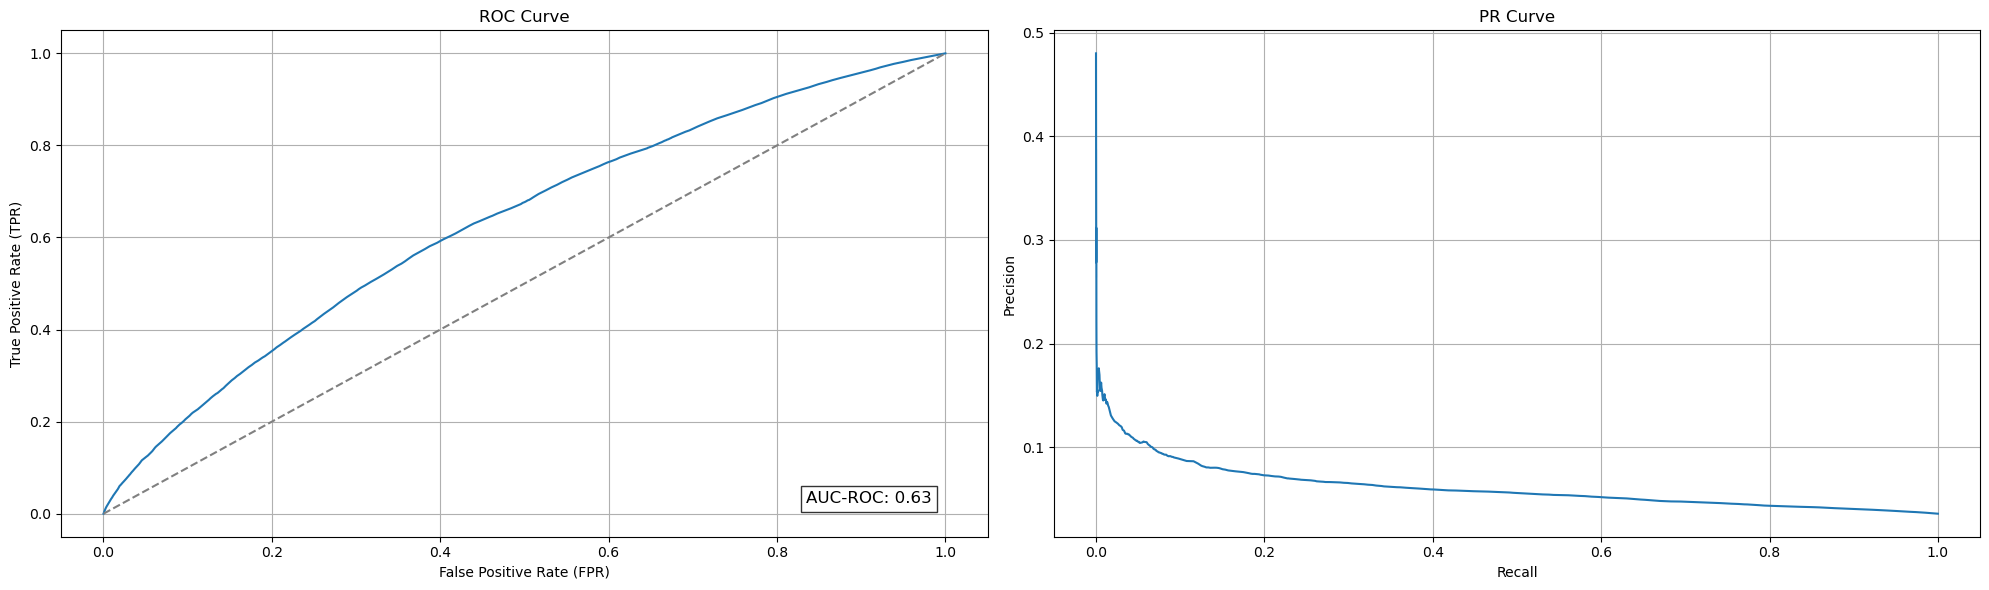

In [53]:
# Рассчитываем AUC ROC
auc_roc = calculate_auc_roc(model=cv_model,
                            test_data=test_real,
                            label_col="flag")
pd_dataframe = calculate_metrics(model=cv_model,
                                 test_data=test_real,
                                 label_col="flag")
plot_roc_pr_curves(pd_dataframe, auc_roc)

Определим вероятность -- границу разделения, при которой `Recall` не меньше 60%.

In [54]:
threshold_probability = pd_dataframe[pd_dataframe['TPR'] >= 0.60]['probability'].max()
print(f"Вероятность -- граница разделения, при которой TPR не меньше 60%: {threshold_probability:.2f}")

Вероятность -- граница разделения, при которой TPR не меньше 60%: 0.50


Рассчитаем метрики на тестовом датасете повторно, с учетом вычисленного `threshold` для вероятности.

In [56]:
cv_model.bestModel.stages[-1].setThresholds([1 - threshold_probability, 
                                             threshold_probability])
test_df_predictions = cv_model.transform(test_real)
metrics = evaluate_model(test_df_predictions, "flag")
print(f"Metrics: {metrics}")

Матрица ошибок:
TP: 12876, FP: 235957
FN: 8591, TN: 341809
Всего записей: 599233
Metrics: {'precision': 0.051745548219086696, 'recall': 0.599804350864117, 'f1': 0.09527192008879024, 'accuracy': 0.5918983100062913}


Не забываем завершать `Spark`-сессию.

In [ ]:
spark.stop()